### Create AnnData object for GSE62784 — Simmini 2014 Cdx2-null intestinal-to-gastric reprogramming

- **Developed by:** Anna Maguza
- **Affiliation:** Faculty of Medicine, Würzburg University
- **Date of creation:** 7 May 2026
- **Last modified date:** 7 May 2026

Builds an AnnData from the small plate count table at `LGR5_analysis_data/GSE62784/`:

| file | shape | description |
|---|---|---|
| `GSE62784_data_counts_ORG.txt` | genes × **19 columns** | 16 cells + 3 `not used for analysis` columns; cells are `Cdx2+ Sto`, `Cdx2null SI`, `Control Sto`, `Control SI` (organoid populations FACS-sorted on Lgr5-EGFP-hi) |
| `GSE62784_BC.txt` | 16 lines | barcode → cell label map |

**Format mismatch with the science doc**: `GSE_datasets_Lgr5_intestinal_stem_cells.md` describes this study as Affymetrix microarray; the deposited files are clearly per-cell plate counts (Smart-Seq / CEL-Seq). The folder wins.

All 16 cells are FACS-sorted Lgr5-EGFP-hi per the Simmini 2014 design (Lgr5-EGFP-CreERT2;Cdx2^fl/fl^ organoids) — `lgr5_status='LGR5+'` for every cell; Cdx2 genotype lives in `condition` and `lgr5_label_raw`. See `LGR5_data_folder_inventory.md` and `GSE_datasets_Lgr5_intestinal_stem_cells.md` (entry §2).

### Import packages

In [1]:
import os
from datetime import datetime

import anndata as ad
import numpy as np
import pandas as pd
import scanpy as sc
import scipy as sci

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/_utils/__init__.py:33: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/__init__.py:24: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/readwrite.py:16: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


### Load count table

In [2]:
DATA_DIR = '/Users/am336941/PhD/data/LGR5_analysis_data/GSE62784'

# header has quoted column names with spaces (e.g. "Cdx2+ Sto_3"); index_col=0 takes the gene IDs
df = pd.read_csv(os.path.join(DATA_DIR, 'GSE62784_data_counts_ORG.txt'), sep='\t', index_col=0, quotechar='"')
# strip __chrN suffix on gene IDs
df.index = df.index.str.split('__').str[0]
# drop the 3 'not used for analysis' columns
df = df.loc[:, [c for c in df.columns if not str(c).lower().startswith('not used')]]
print('genes:', df.shape[0], '| cells:', df.shape[1])
df.columns.tolist()

genes: 18315 | cells: 16


['Cdx2+ Sto_3',
 'Cdx2+ Sto_4',
 'Cdx2+ Sto_2',
 'Cdx2+ Sto_1',
 'Cdx2null SI_2',
 'Cdx2null SI_1',
 'Cdx2null SI_4',
 'Control Sto_2',
 'Control Sto_1',
 'Control Sto_4',
 'Control Sto_3',
 'Control SI_2',
 'Control SI_1',
 'Control SI_4',
 'Control SI_3',
 'Cdx2null SI_3']

In [3]:
# Parse cell labels into population/tissue/replicate, e.g. 'Cdx2+ Sto_3' -> Cdx2+, Sto, rep 3
def parse_label(label):
    head, _, rep = label.rpartition('_')
    pop, _, region = head.rpartition(' ')
    if region == 'Sto':
        tissue = 'pyloric stomach'
    elif region == 'SI':
        tissue = 'small intestine'
    else:
        tissue = region
    return pop.strip(), tissue, int(rep)

obs_rows = []
for label in df.columns:
    pop, tissue, rep = parse_label(label)
    if pop == 'Cdx2+':
        condition, label_raw = 'Cdx2-overexpression', 'Cdx2+_Lgr5-EGFP-high'
    elif pop == 'Cdx2null':
        condition, label_raw = 'Cdx2-null', 'Cdx2null_Lgr5-EGFP-high'
    elif pop == 'Control':
        condition, label_raw = 'Control', 'Control_Lgr5-EGFP-high'
    else:
        condition, label_raw = pop, f'{pop}_Lgr5-EGFP-high'
    obs_rows.append({
        'cell_id': label.replace(' ', '_'),
        'sample': label.replace(' ', '_'),
        'population': pop,
        'tissue': tissue,
        'replicate': rep,
        'condition': condition,
        'lgr5_status': 'LGR5+',
        'lgr5_label_raw': label_raw,
        'cell_type': 'Lgr5+ ISC organoid',
    })
obs = pd.DataFrame(obs_rows).set_index('cell_id')
obs

,sample,population,tissue,replicate,condition,lgr5_status,lgr5_label_raw,cell_type
cell_id,,,,,,,,
Cdx2+_Sto_3,Cdx2+_Sto_3,Cdx2+,pyloric stomach,3,Cdx2-overexpression,LGR5+,Cdx2+_Lgr5-EGFP-high,Lgr5+ ISC organoid
Cdx2+_Sto_4,Cdx2+_Sto_4,Cdx2+,pyloric stomach,4,Cdx2-overexpression,LGR5+,Cdx2+_Lgr5-EGFP-high,Lgr5+ ISC organoid
Cdx2+_Sto_2,Cdx2+_Sto_2,Cdx2+,pyloric stomach,2,Cdx2-overexpression,LGR5+,Cdx2+_Lgr5-EGFP-high,Lgr5+ ISC organoid
Cdx2+_Sto_1,Cdx2+_Sto_1,Cdx2+,pyloric stomach,1,Cdx2-overexpression,LGR5+,Cdx2+_Lgr5-EGFP-high,Lgr5+ ISC organoid
Cdx2null_SI_2,Cdx2null_SI_2,Cdx2null,small intestine,2,Cdx2-null,LGR5+,Cdx2null_Lgr5-EGFP-high,Lgr5+ ISC organoid
Cdx2null_SI_1,Cdx2null_SI_1,Cdx2null,small intestine,1,Cdx2-null,LGR5+,Cdx2null_Lgr5-EGFP-high,Lgr5+ ISC organoid
Cdx2null_SI_4,Cdx2null_SI_4,Cdx2null,small intestine,4,Cdx2-null,LGR5+,Cdx2null_Lgr5-EGFP-high,Lgr5+ ISC organoid
Control_Sto_2,Control_Sto_2,Control,pyloric stomach,2,Control,LGR5+,Control_Lgr5-EGFP-high,Lgr5+ ISC organoid
Control_Sto_1,Control_Sto_1,Control,pyloric stomach,1,Control,LGR5+,Control_Lgr5-EGFP-high,Lgr5+ ISC organoid


In [4]:
# Reorder columns to match obs index, then transpose to cells × genes
rename_map = {old: old.replace(' ', '_') for old in df.columns}
df = df.rename(columns=rename_map)
expr = df[obs.index].T  # cells × genes
var = pd.DataFrame(index=expr.columns)
var.index.name = None
adata = ad.AnnData(X=sci.sparse.csr_matrix(expr.values), obs=obs, var=var)
adata.var_names_make_unique()
adata.obs['GSE'] = 'GSE62784'
adata.obs['organism'] = 'mus musculus'
adata.obs['technology'] = 'CEL-Seq'
adata.obs['assay_modality'] = 'single-cell'
for col in ['sample', 'population', 'tissue', 'condition', 'lgr5_status', 'lgr5_label_raw', 'cell_type', 'GSE', 'organism', 'technology', 'assay_modality']:
    adata.obs[col] = adata.obs[col].astype('category')
adata

/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/anndata/_core/anndata.py:1798: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


AnnData object with n_obs × n_vars = 16 × 18315
    obs: 'sample', 'population', 'tissue', 'replicate', 'condition', 'lgr5_status', 'lgr5_label_raw', 'cell_type', 'GSE', 'organism', 'technology', 'assay_modality'

### QC + sanity check

In [5]:
adata.var['mt']   = adata.var_names.str.startswith('mt-')
adata.var['ribo'] = adata.var_names.str.match(r'^Rp[sl]')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt', 'ribo'], inplace=True, percent_top=None, log1p=False)
adata.obs[['n_genes_by_counts', 'total_counts', 'pct_counts_mt', 'pct_counts_ribo']].describe()

,n_genes_by_counts,total_counts,pct_counts_mt,pct_counts_ribo
count,16.000000,1.600000e+01,16.0,16.000000
mean,13533.562500,2.888634e+06,0.0,22.884181
std,672.245587,2.157209e+06,0.0,2.266985
min,12579.000000,1.164623e+06,0.0,20.411040
25%,13044.750000,1.711482e+06,0.0,21.330505
50%,13349.000000,2.044914e+06,0.0,22.394742
75%,13919.750000,2.861696e+06,0.0,23.676079
max,14983.000000,9.421524e+06,0.0,29.088885


/Users/am336941/uv_envs/pyenv313/.venv/lib/python3.11/site-packages/scanpy/plotting/_anndata.py:2074: FutureWarning: Use obs (e.g. `k in adata.obs` or `str(adata.obs.columns.tolist())`) instead of AnnData.obs_keys, AnnData.obs_keys is deprecated and will be removed in the future.
  if group not in [*adata.obs_keys(), adata.obs.index.name]:


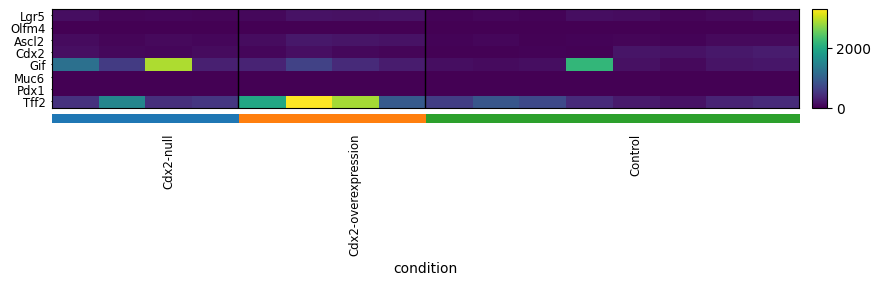

In [6]:
markers = [g for g in ['Lgr5', 'Olfm4', 'Ascl2', 'Cdx2', 'Gif', 'Muc6', 'Pdx1', 'Tff2'] if g in adata.var_names]
if markers:
    sc.pl.heatmap(adata, var_names=markers, groupby='condition', swap_axes=True, dendrogram=False)

### Save

In [7]:
timestamp = datetime.now().strftime('%d%m%Y_%H%M%S')
adata.uns['GSE'] = 'GSE62784'
adata.uns['publication'] = 'Simmini S et al., Nat Commun 5:5728 (2014) — Transformation of intestinal stem cells into gastric stem cells on loss of Cdx2'
adata.uns['genome_reference'] = 'mm9 (per Simmini 2014; __chrN suffix on gene IDs preserved)'
adata.uns['source_files'] = ['GSE62784_data_counts_ORG.txt', 'GSE62784_BC.txt']
adata.uns['processing_history'] = {
    timestamp: 'AnnData created from GSE62784_data_counts_ORG.txt; 3 "not used for analysis" columns dropped; __chrN suffix stripped; lgr5_status=LGR5+ uniformly (all cells from Lgr5-EGFP-hi sort); QC metrics computed; no filtering applied. | note: Despite the science doc citing Affymetrix microarray, deposited files are per-cell plate counts (CEL-Seq / Smart-Seq) — folder is the source of truth.',
}

out_dir = 'data/LGR5_analysis'
os.makedirs(out_dir, exist_ok=True)
out_path = f'{out_dir}/gut_mm_GSE62784_AM_{timestamp}_raw.h5ad'
adata.write_h5ad(out_path)
print(out_path, adata.shape)

data/LGR5_analysis/gut_mm_GSE62784_AM_07052026_230514_raw.h5ad (16, 18315)
